# 01 - Data Exploration: MetroAT Dataset

**Thesis:** Structured Subsystem-Aware Feature Representations for Predictive Maintenance in Metro Systems  
**Author:** Emirhan Kurtulus, TU Wien

This notebook explores the MetroAT benchmark dataset to understand its structure,
sensor subsystems, failure events, and temporal characteristics — laying the
groundwork for Phase 1 (RQ1): constructing subsystem-aware feature representations
from recurring anomaly patterns.

**Sections:**
1. Dataset Overview
2. Sensor Subsystems
3. Failure & Maintenance Events
4. Full Timeline Visualization
5. Sensor Distributions: Normal vs Failure
6. Subsystem Correlation Analysis
7. Missing Values

## 0. Setup

In [1]:
import sys, os, gc
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.abspath('..'))
from src.config import SUBSYSTEMS, SPLIT_DATE

ROOT = os.path.abspath('..')
TRAIN_GLOB = os.path.join(ROOT, 'train', '**', '*.parquet')
TEST_GLOB  = os.path.join(ROOT, 'test',  '**', '*.parquet')

plt.rcParams['figure.figsize'] = (18, 4)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

# Reverse lookup: column -> subsystem
_col_to_sub = {col: ss for ss, cols in SUBSYSTEMS.items() for col in cols}
def get_subsystem(col):
    return _col_to_sub.get(col, 'Unknown')

META_COLS = ['TIMESTAMP', 'TRAIN_IS_IN_FAILURE', 'TRAIN_FAILURE_TYPE',
             'TRAIN_IS_IN_MAINTENANCE', 'TRAIN_MAINTENANCE_TYPE',
             'year', 'month', 'day']

print('Setup done.')

Setup done.


## 1. Dataset Overview

In [2]:
def load_split(glob_pattern, label):
    files = sorted(glob.glob(glob_pattern, recursive=True))
    print(f'[{label}] Loading {len(files)} files...')
    df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
    df['TIMESTAMP'] = pd.to_datetime(df['TIMESTAMP'])
    df.sort_values('TIMESTAMP', inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f'[{label}] {len(df):,} rows | {df["TIMESTAMP"].min().date()} to {df["TIMESTAMP"].max().date()}')
    return df

train = load_split(TRAIN_GLOB, 'TRAIN')
gc.collect()
test = load_split(TEST_GLOB, 'TEST')
gc.collect()

print(f'\nTotal: {len(train) + len(test):,} rows')
print(f'Columns: {len(train.columns)}')

[TRAIN] Loading 246 files...


[TRAIN] 14,342,361 rows | 2024-06-01 to 2025-02-11


[TEST] Loading 136 files...


[TEST] 7,901,921 rows | 2025-02-12 to 2025-06-30

Total: 22,244,282 rows
Columns: 109


In [3]:
# Sensor columns (exclude metadata)
sensor_cols = [c for c in train.columns if c not in META_COLS]
print(f'Sensor columns: {len(sensor_cols)}')
print(f'Sampling rate: {train["TIMESTAMP"].iloc[:10000].diff().dt.total_seconds().median():.0f}s (median)')
print()

# Class distribution per split
for label, df in [('TRAIN', train), ('TEST', test)]:
    total = len(df)
    f = df['TRAIN_IS_IN_FAILURE'].sum()
    m = df['TRAIN_IS_IN_MAINTENANCE'].sum()
    n = total - f - m
    print(f'{label}: {total:>10,} rows | '
          f'Failure {f:>7,} ({100*f/total:.2f}%) | '
          f'Maintenance {m:>7,} ({100*m/total:.2f}%) | '
          f'Normal {n:>10,} ({100*n/total:.2f}%)')

Sensor columns: 101
Sampling rate: 1s (median)

TRAIN: 14,342,361 rows | Failure 137,489 (0.96%) | Maintenance 649,291 (4.53%) | Normal 13,555,581 (94.51%)
TEST:  7,901,921 rows | Failure 113,467 (1.44%) | Maintenance 290,301 (3.67%) | Normal  7,498,153 (94.89%)


## 2. Sensor Subsystems

The MetroAT dataset monitors a 6-wagon metro train (2 control wagons CW1/CW2 + 4 middle wagons MW1-MW4).
Sensors are grouped into functional subsystems based on domain knowledge from the CIRP CMS 2026 paper.

In [4]:
# Subsystem breakdown
subsystem_map = {c: get_subsystem(c) for c in sensor_cols}
counts = Counter(subsystem_map.values())

print('Sensor Subsystem Breakdown:')
for ss in ['APU', 'Brake', 'Leveling', 'Traction', 'Context']:
    n = counts.get(ss, 0)
    print(f'  {ss:12s}: {n:3d} sensors')
unknown = [c for c in sensor_cols if get_subsystem(c) == 'Unknown']
if unknown:
    print(f'  {"Unknown":12s}: {len(unknown):3d} sensors: {unknown}')
print(f'  {"TOTAL":12s}: {len(sensor_cols):3d}')

# Data types
n_float32 = sum(1 for c in sensor_cols if train[c].dtype == np.float32)
n_float64 = sum(1 for c in sensor_cols if train[c].dtype == np.float64)
n_int = sum(1 for c in sensor_cols if train[c].dtype in [np.int64, np.int32])
print(f'\nData types: float32={n_float32}, float64={n_float64}, int={n_int}')

Sensor Subsystem Breakdown:
  APU         :   4 sensors
  Brake       :  67 sensors
  Leveling    :  18 sensors
  Traction    :   4 sensors
  Context     :   8 sensors
  TOTAL       : 101

Data types: float32=78, float64=23, int=0


## 3. Failure & Maintenance Events

Failure events are continuous blocks of `TRAIN_IS_IN_FAILURE == True`.
These are the target events our predictive maintenance models aim to anticipate.

In [5]:
def get_events(df, flag_col, type_col):
    """Extract continuous event blocks from a boolean flag column."""
    tmp = df[['TIMESTAMP', flag_col, type_col]].copy()
    tmp['_grp'] = (tmp[flag_col] != tmp[flag_col].shift()).cumsum()
    events = (
        tmp[tmp[flag_col]]
        .groupby('_grp')
        .agg(start=('TIMESTAMP', 'min'), end=('TIMESTAMP', 'max'),
             event_type=(type_col, 'first'), n_rows=('TIMESTAMP', 'count'))
        .reset_index(drop=True)
    )
    events.index += 1
    events.index.name = 'event'
    events['duration_h'] = (events['end'] - events['start']).dt.total_seconds() / 3600
    return events

train_failures = get_events(train, 'TRAIN_IS_IN_FAILURE', 'TRAIN_FAILURE_TYPE')
test_failures  = get_events(test,  'TRAIN_IS_IN_FAILURE', 'TRAIN_FAILURE_TYPE')
train_maint    = get_events(train, 'TRAIN_IS_IN_MAINTENANCE', 'TRAIN_MAINTENANCE_TYPE')
test_maint     = get_events(test,  'TRAIN_IS_IN_MAINTENANCE', 'TRAIN_MAINTENANCE_TYPE')

print(f'TRAIN: {len(train_failures)} failure events, {len(train_maint)} maintenance events')
print(f'TEST:  {len(test_failures)} failure events, {len(test_maint)} maintenance events')

TRAIN: 10 failure events, 10 maintenance events
TEST:  11 failure events, 8 maintenance events


In [6]:
# Failure event details
print('=== TRAIN Failure Events ===')
print(train_failures[['start', 'end', 'duration_h', 'event_type', 'n_rows']].to_string())
print()
print('=== TEST Failure Events ===')
print(test_failures[['start', 'end', 'duration_h', 'event_type', 'n_rows']].to_string())

=== TRAIN Failure Events ===
                    start                 end  duration_h                 event_type  n_rows
event                                                                                       
1     2024-06-27 15:47:30 2024-06-27 17:52:28    2.082778       Brake System Failure    7185
2     2024-08-19 10:37:51 2024-08-19 11:05:44    0.464722       Brake System Failure    1611
3     2024-08-27 15:58:43 2024-08-28 21:29:25   29.511667    Leveling System Failure   32532
4     2024-09-03 05:04:00 2024-09-03 07:33:36    2.493333       Brake System Failure    8469
5     2024-09-22 05:49:43 2024-09-22 08:14:45    2.417222       Brake System Failure    6122
6     2024-10-06 02:04:15 2024-10-08 09:15:36   55.189167       Brake System Failure   42540
7     2024-10-10 11:19:48 2024-10-10 15:35:49    4.266944       Brake System Failure    8420
8     2024-10-31 15:08:06 2024-10-31 18:26:02    3.298889  Compressor Module Failure    8064
9     2024-12-14 18:56:40 2024-12-14 23:3

In [7]:
# Failure type summary
all_failures = pd.concat([
    train_failures.assign(split='train'),
    test_failures.assign(split='test')
])
print('Failure type breakdown:')
print(all_failures.groupby(['split', 'event_type']).size().unstack(fill_value=0).to_string())
print()
print('Duration stats (hours):')
print(all_failures.groupby('event_type')['duration_h'].describe().round(2).to_string())

Failure type breakdown:
event_type  Brake System Failure  Compressor Module Failure  Leveling System Failure
split                                                                               
test                           5                          5                        1
train                          8                          1                        1

Duration stats (hours):
                           count   mean    std   min   25%    50%    75%     max
event_type                                                                      
Brake System Failure        13.0   8.01  14.51  0.46  2.42   3.73   4.88   55.19
Compressor Module Failure    6.0  27.14  55.35  0.17  2.79   4.25  10.10  139.84
Leveling System Failure      2.0  16.34  18.62  3.18  9.76  16.34  22.93   29.51


## 4. Full Timeline Visualization

Visualize the entire observation period with failure events (colored by type),
maintenance intervals (grey), and the train/test split boundary.

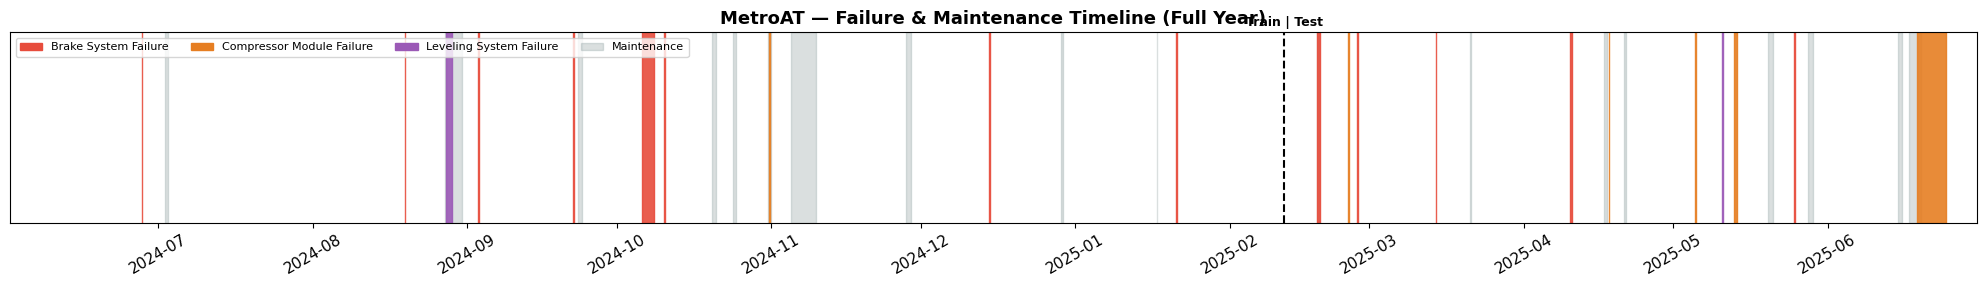

In [8]:
TYPE_COLORS = {
    'Brake System Failure':      '#e74c3c',
    'Compressor Module Failure': '#e67e22',
    'Leveling System Failure':   '#9b59b6',
}
MAINT_COLOR = '#95a5a6'

fig, ax = plt.subplots(figsize=(20, 3))

# Maintenance blocks
for _, row in pd.concat([train_maint, test_maint]).iterrows():
    ax.axvspan(row['start'], row['end'], color=MAINT_COLOR, alpha=0.35, zorder=0)

# Train/test split
split_date = train['TIMESTAMP'].max()
ax.axvline(split_date, color='black', linestyle='--', linewidth=1.5, zorder=3)
ax.text(split_date, 1.02, 'Train | Test', transform=ax.get_xaxis_transform(),
        va='bottom', ha='center', fontsize=9, fontweight='bold')

# Failure events
for events in [train_failures, test_failures]:
    for _, row in events.iterrows():
        color = TYPE_COLORS.get(row['event_type'], 'grey')
        ax.axvspan(row['start'], row['end'], color=color, alpha=0.9, zorder=2)

patches = [Patch(color=c, label=t) for t, c in TYPE_COLORS.items()]
patches.append(Patch(color=MAINT_COLOR, alpha=0.35, label='Maintenance'))
ax.legend(handles=patches, loc='upper left', fontsize=8, ncol=4)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=30)
ax.set_yticks([])
ax.set_xlim(train['TIMESTAMP'].min(), test['TIMESTAMP'].max())
ax.set_title('MetroAT — Failure & Maintenance Timeline (Full Year)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

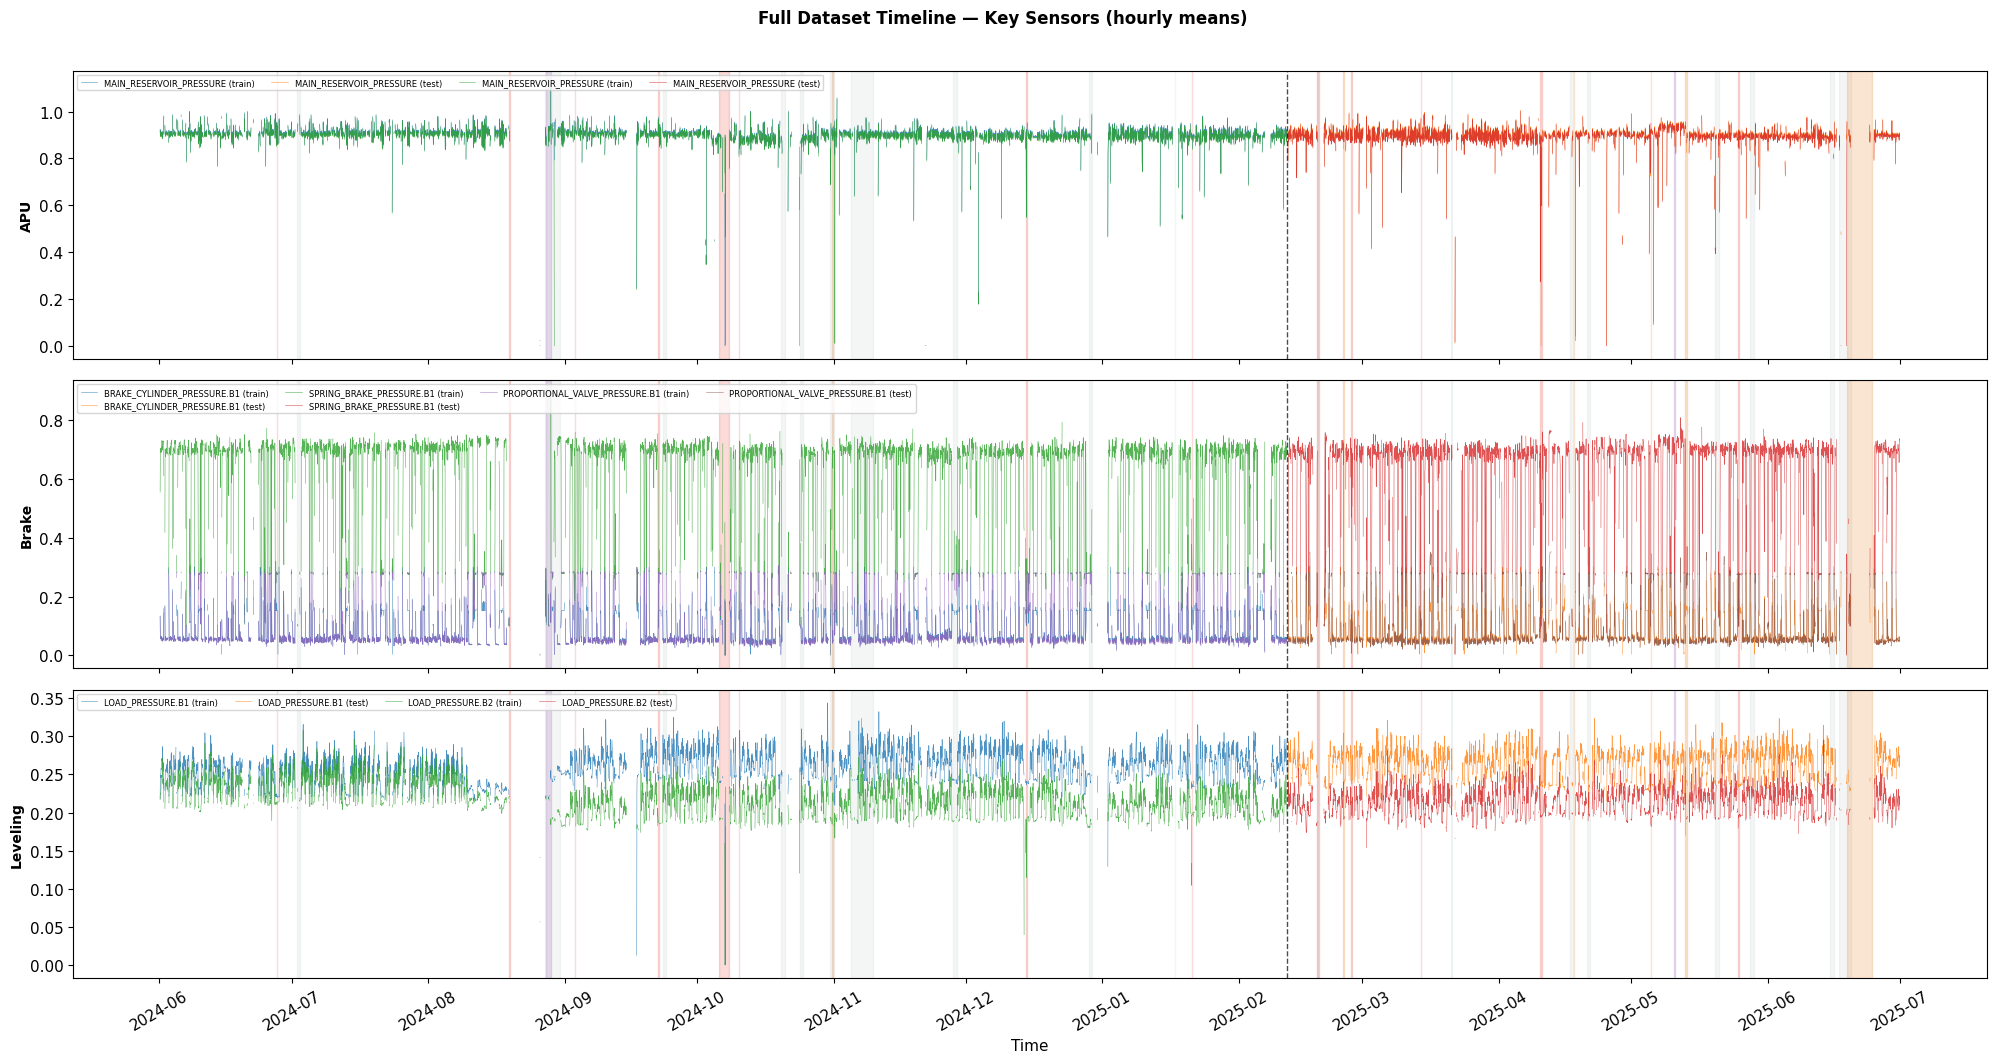

Done.


In [9]:
# Full-timeline sensor plots — hourly downsampled
PLOT_SENSORS = {
    'APU':      ['CW1_MAIN_RESERVOIR_PRESSURE', 'CW2_MAIN_RESERVOIR_PRESSURE'],
    'Brake':    ['CW1_BRAKE_CYLINDER_PRESSURE_BOGIE1', 'CW1_SPRING_BRAKE_PRESSURE_BOGIE1',
                 'CW1_PROPORTIONAL_VALVE_PRESSURE_BOGIE1'],
    'Leveling': ['CW1_LOAD_PRESSURE_BOGIE1', 'CW1_LOAD_PRESSURE_BOGIE2'],
}

all_plot_cols = [s for sensors in PLOT_SENSORS.values() for s in sensors]

train_h = train[['TIMESTAMP'] + all_plot_cols].set_index('TIMESTAMP').resample('1h').mean()
test_h  = test[['TIMESTAMP'] + all_plot_cols].set_index('TIMESTAMP').resample('1h').mean()

fig, axes = plt.subplots(len(PLOT_SENSORS), 1, figsize=(20, 3.5 * len(PLOT_SENSORS)), sharex=True)
fig.suptitle('Full Dataset Timeline — Key Sensors (hourly means)',
             fontsize=12, fontweight='bold', y=1.01)

for ax, (subsystem, sensors) in zip(axes, PLOT_SENSORS.items()):
    for sensor in sensors:
        short = sensor.replace('CW1_','').replace('CW2_','').replace('_BOGIE1','.B1').replace('_BOGIE2','.B2')
        ax.plot(train_h.index, train_h[sensor], linewidth=0.4, alpha=0.8, label=f'{short} (train)')
        ax.plot(test_h.index, test_h[sensor], linewidth=0.4, alpha=0.8, label=f'{short} (test)')

    for events in [train_failures, test_failures]:
        for _, ev in events.iterrows():
            ax.axvspan(ev['start'], ev['end'], color=TYPE_COLORS.get(ev['event_type'],'grey'), alpha=0.2)
    for _, m in pd.concat([train_maint, test_maint]).iterrows():
        ax.axvspan(m['start'], m['end'], color=MAINT_COLOR, alpha=0.1)

    ax.axvline(split_date, color='black', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_ylabel(subsystem, fontsize=10, fontweight='bold')
    ax.legend(fontsize=6, loc='upper left', ncol=4)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].set_xlabel('Time')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

del train_h, test_h; gc.collect()
print('Done.')

## 5. Sensor Distributions: Normal vs Failure

Compare how key sensor values differ between normal operation and failure periods.
This motivates which sensors carry discriminative signal for predictive maintenance.

In [10]:
normal_mask  = ~train['TRAIN_IS_IN_FAILURE'] & ~train['TRAIN_IS_IN_MAINTENANCE']
failure_mask = train['TRAIN_IS_IN_FAILURE'].astype(bool)

key_sensors = [
    'CW1_MAIN_RESERVOIR_PRESSURE', 'CW2_MAIN_RESERVOIR_PRESSURE',
    'CW1_BRAKE_CYLINDER_PRESSURE_BOGIE1', 'CW1_SPRING_BRAKE_PRESSURE_BOGIE1',
    'CW1_PROPORTIONAL_VALVE_PRESSURE_BOGIE1',
    'CW1_LOAD_PRESSURE_BOGIE1', 'CW1_LOAD_SIGNAL',
]

# Stats table
rows = []
for s in key_sensors:
    col = train[s]
    rows.append({
        'sensor': s, 'subsystem': get_subsystem(s),
        'normal_mean':  float(col[normal_mask].mean()),
        'normal_std':   float(col[normal_mask].std()),
        'failure_mean': float(col[failure_mask].mean()),
        'failure_std':  float(col[failure_mask].std()),
    })
stats = pd.DataFrame(rows).set_index('sensor')
stats['mean_diff'] = (stats['failure_mean'] - stats['normal_mean']).round(4)
print(stats[['subsystem', 'normal_mean', 'failure_mean', 'mean_diff', 'normal_std', 'failure_std']].round(4).to_string())

                                       subsystem  normal_mean  failure_mean  mean_diff  normal_std  failure_std
sensor                                                                                                         
CW1_MAIN_RESERVOIR_PRESSURE                  APU       0.9038        0.8557    -0.0481      0.0597       0.2110
CW2_MAIN_RESERVOIR_PRESSURE                  APU       0.8989        0.8821    -0.0168      0.0605       0.1414
CW1_BRAKE_CYLINDER_PRESSURE_BOGIE1         Brake       0.0755        0.1248     0.0493      0.1017       0.1218
CW1_SPRING_BRAKE_PRESSURE_BOGIE1           Brake       0.6157        0.3141    -0.3017      0.1983       0.2323
CW1_PROPORTIONAL_VALVE_PRESSURE_BOGIE1     Brake       0.0950        0.1826     0.0876      0.1112       0.1118
CW1_LOAD_PRESSURE_BOGIE1                Leveling       0.2619        0.2262    -0.0357      0.0343       0.0545
CW1_LOAD_SIGNAL                         Leveling       0.0624        0.0522    -0.0102      0.1104      

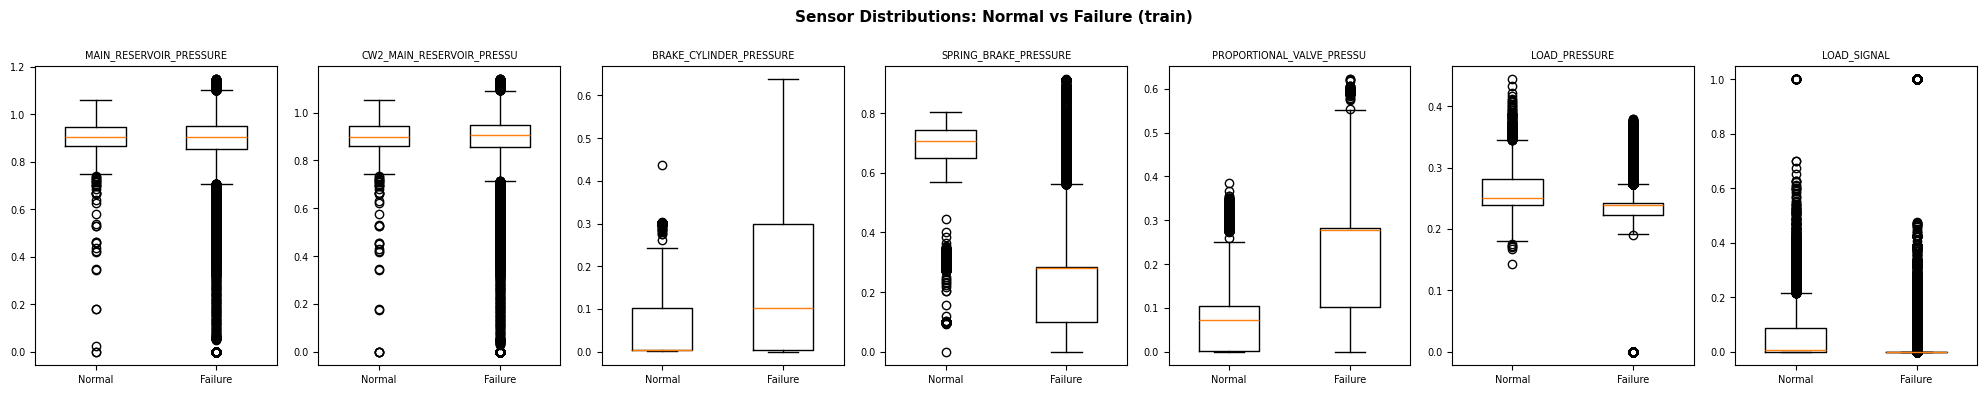

21294

In [11]:
# Box plots
fig, axes = plt.subplots(1, len(key_sensors), figsize=(20, 4))
for ax, sensor in zip(axes, key_sensors):
    col = train[sensor]
    norm_vals = col[normal_mask].dropna()
    fail_vals = col[failure_mask].dropna()
    if len(norm_vals) > 10000:
        norm_vals = norm_vals.sample(10000, random_state=42)
    ax.boxplot([norm_vals, fail_vals], labels=['Normal', 'Failure'], widths=0.5)
    short = sensor.replace('CW1_', '').replace('_BOGIE1', '')[:25]
    ax.set_title(short, fontsize=7)
    ax.tick_params(labelsize=7)
plt.suptitle('Sensor Distributions: Normal vs Failure (train)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

del normal_mask, failure_mask; gc.collect()

## 6. Subsystem Correlation Analysis

Compute Pearson correlations between sensors, grouped by subsystem.
High within-subsystem correlation validates that sensors within a subsystem share functional information,
motivating subsystem-level feature representations (RQ1).

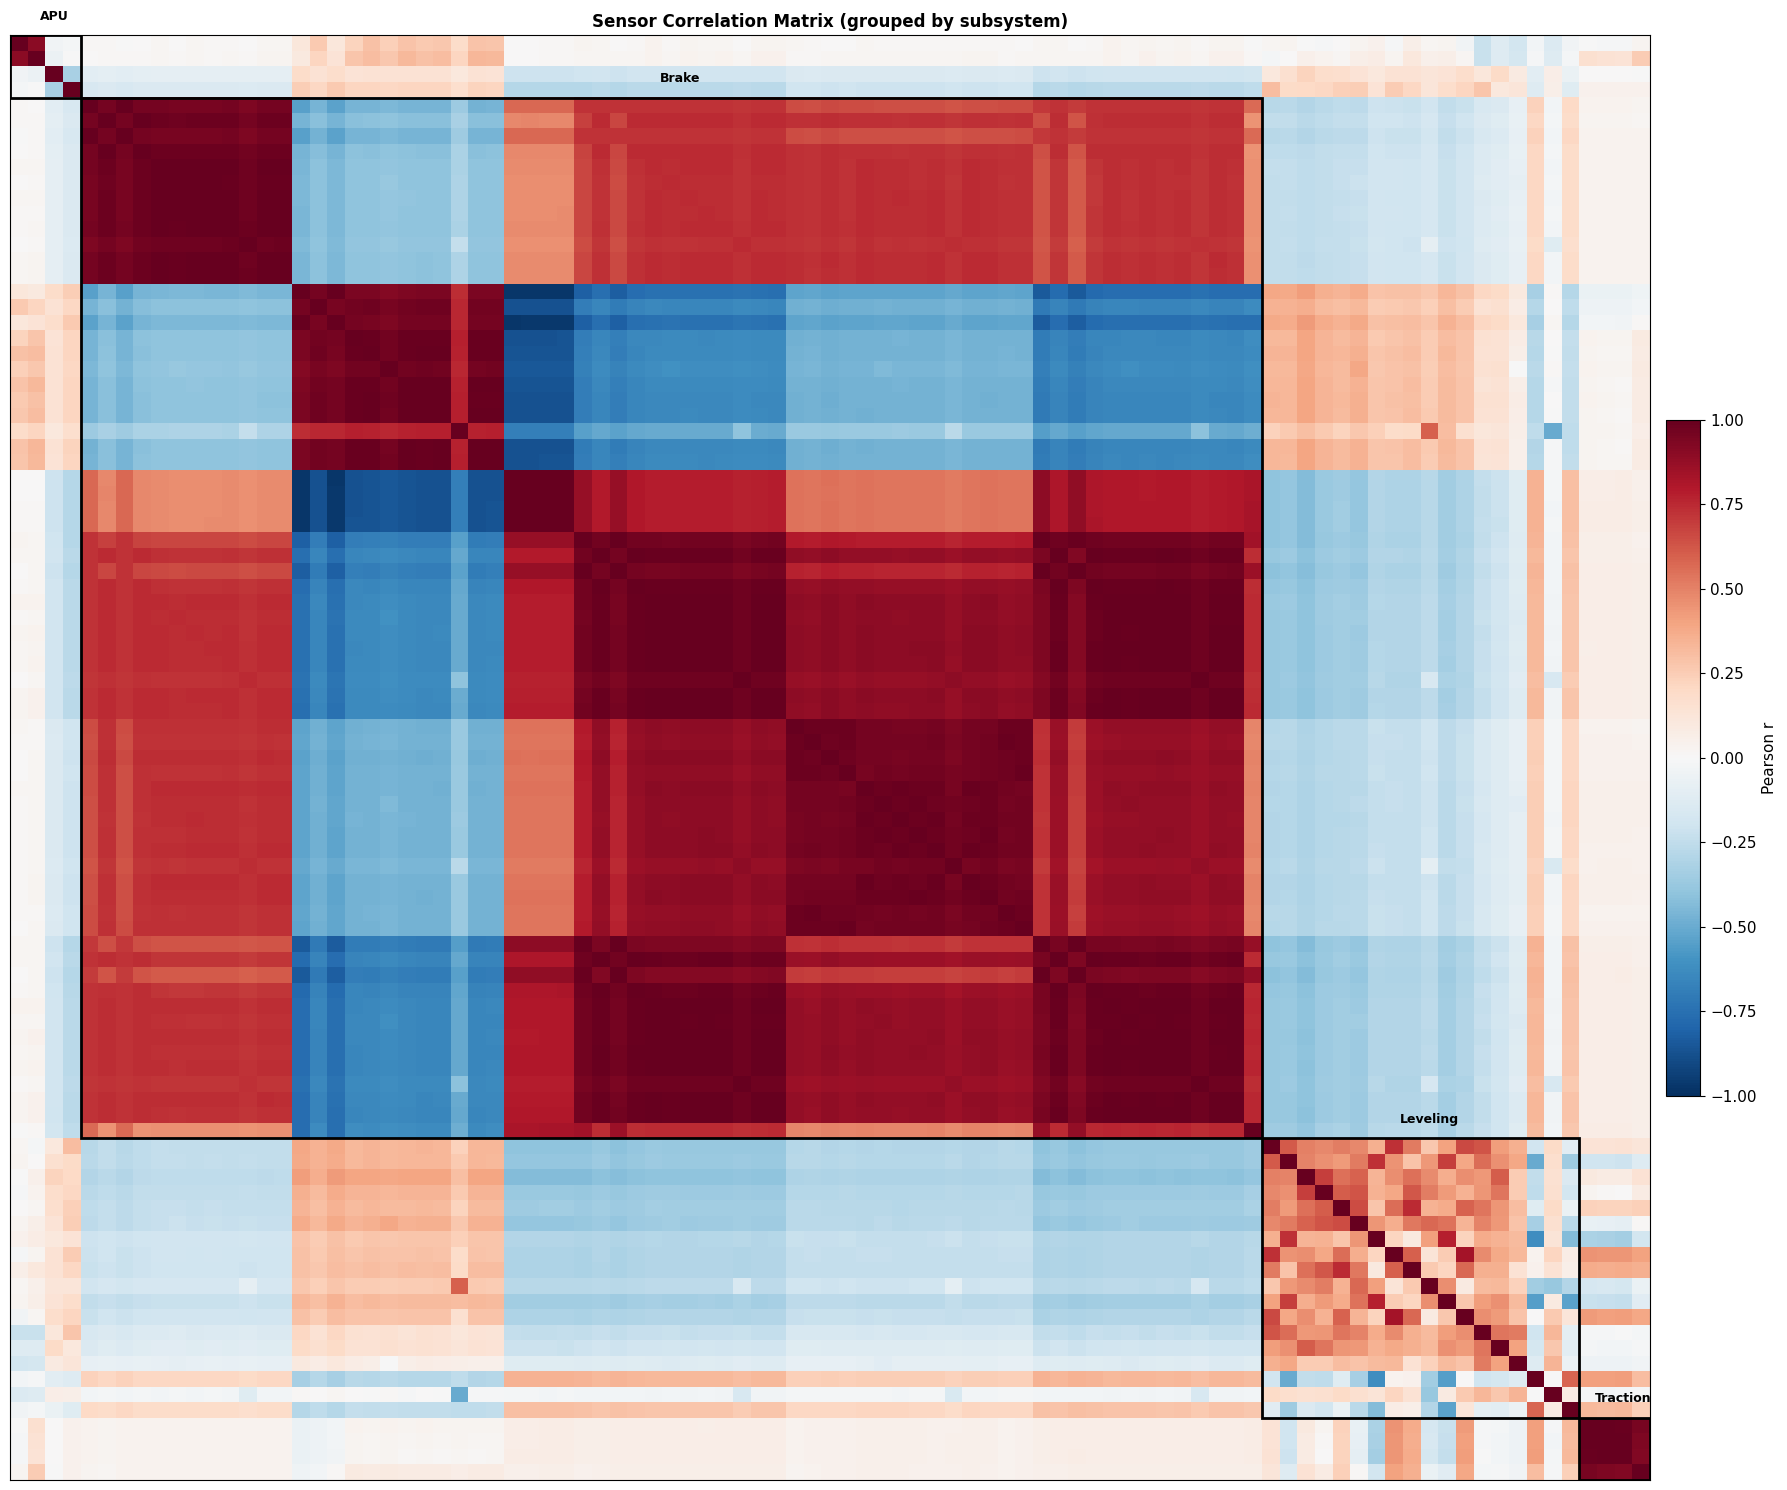

Mean |Pearson r|:
  Within  APU       : 0.223
  Within  Brake     : 0.745
  Within  Leveling  : 0.370
  Within  Traction  : 0.966
  APU        <-> Brake     : 0.125
  APU        <-> Leveling  : 0.111
  APU        <-> Traction  : 0.058
  Brake      <-> Leveling  : 0.254
  Brake      <-> Traction  : 0.050
  Leveling   <-> Traction  : 0.187


In [12]:
# Group sensors by subsystem (exclude Context — mostly categorical/binary)
CORR_SUBSYSTEMS = ['APU', 'Brake', 'Leveling', 'Traction']
ordered_cols = []
boundaries = []
for ss in CORR_SUBSYSTEMS:
    start = len(ordered_cols)
    cols = [c for c in SUBSYSTEMS[ss] if c in train.columns]
    ordered_cols.extend(cols)
    boundaries.append((start, len(ordered_cols), ss))

# Sample 200k rows for memory efficiency
sample = train[ordered_cols].sample(min(200_000, len(train)), random_state=42)
corr_matrix = sample.corr()
del sample; gc.collect()

fig, ax = plt.subplots(figsize=(18, 15))
im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.02, pad=0.01, label='Pearson r')

for start, end, name in boundaries:
    rect = plt.Rectangle((start-0.5, start-0.5), end-start, end-start,
                         linewidth=2, edgecolor='black', facecolor='none')
    ax.add_patch(rect)
    ax.text(start + (end-start)/2, start-1.5, name, fontsize=9,
            fontweight='bold', ha='center', color='black')

ax.set_xticks([])
ax.set_yticks([])
ax.set_title('Sensor Correlation Matrix (grouped by subsystem)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Within vs cross-subsystem mean |r|
print('Mean |Pearson r|:')
for s1, e1, n1 in boundaries:
    within = np.abs(corr_matrix.iloc[s1:e1, s1:e1].values).copy()
    np.fill_diagonal(within, np.nan)
    print(f'  Within  {n1:10s}: {np.nanmean(within):.3f}')
for i in range(len(boundaries)):
    for j in range(i+1, len(boundaries)):
        s1, e1, n1 = boundaries[i]
        s2, e2, n2 = boundaries[j]
        cross = np.abs(corr_matrix.iloc[s1:e1, s2:e2].values)
        print(f'  {n1:10s} <-> {n2:10s}: {np.nanmean(cross):.3f}')

## 7. Missing Values

In [13]:
null_counts = pd.Series({c: int(train[c].isnull().sum()) for c in sensor_cols})
null_cols = null_counts[null_counts > 0].sort_values(ascending=False)

print(f'Sensors with missing values: {len(null_cols)} / {len(sensor_cols)}')
if len(null_cols) > 0:
    print(null_cols.to_string())
    print(f'\nTotal missing: {null_cols.sum():,}')
else:
    print('No missing values in sensor columns.')

Sensors with missing values: 3 / 101
TRAIN_LINE                  155286
TRAIN_CURRENT_SECTION       155286
TRAIN_IS_SPECIAL_SECTION    155286

Total missing: 465,858


## Summary

Key findings from data exploration:

- **Dataset:** ~22M rows at 1Hz, 101 sensor columns across 5 subsystems
- **Failures:** 21 events (10 train + 11 test) — Brake, Compressor, Leveling types
- **Class imbalance:** ~1% failure, ~4% maintenance, ~95% normal
- **Subsystem structure:** Within-subsystem correlations are significantly higher than cross-subsystem
- **Sensor behavior:** Key sensors (spring brake pressure, proportional valve, reservoir pressure) show measurable shifts during failure

These findings motivate Phase 1 (RQ1): constructing subsystem-aware feature representations from recurring anomaly patterns through clustering and pattern analysis.